# Day 2: Linear Models

Exercises:
1. Linear regression with batch gradient descent from scratch
2. Loss curve plotting with different learning rates
3. Normal equation implementation
4. Mini-batch gradient descent
5. Polynomial features — overfitting vs underfitting
6. Feature standardization
7. Compare against sklearn

In [43]:
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1: Linear Regression with Batch Gradient Descent

Generate synthetic data `y = 3x + 7 + noise` and fit it using gradient descent.

In [44]:
# Generate synthetic data
np.random.seed(42)
n = 100
X = np.random.randn(n, 1)
y = 3 * X + 7 + np.random.randn(n, 1) * 0.5  # true: w=3, b=7
print(X.shape[0])

100


In [45]:
# Implement linear regression with batch gradient descent
# X is (n, 1), y is (n, 1)
# Fit y = w*x + b by finding optimal w and b
#
# MSE loss: L = (1/n) * sum((y - (Xw + b))^2)
# Gradients:
#   dL/dw = (-2/n) * X.T @ (y - y_hat)
#   dL/db = (-2/n) * sum(y - y_hat)
#
# Your code here:

def gradient_descent(X, y, w, b, iterations= 10, learning_rate=.01):
    n = X.shape[0]
    for i in range(iterations):
        # compute the gradient 
        y_hat = X * w + b
        dL_dw = (-2/n) * X.T @ (y - y_hat)
        dL_db = (-2/n) * sum(y - y_hat)

        w -= (learning_rate * dL_dw)
        b -= (learning_rate * dL_db)

    return w, b

# test the gradient function
w, b = 1, 1 # initial guess for w1 and w0
result = gradient_descent(X, y, w, b, 1000)

print("Result: ", result)




Result:  (array([[2.92837083]]), array([7.00371363]))


## Exercise 2: Learning Rate Experiments
Try learning rates of 0.0001, 0.01, 0.1, and 1.0. Plot the loss curve for each

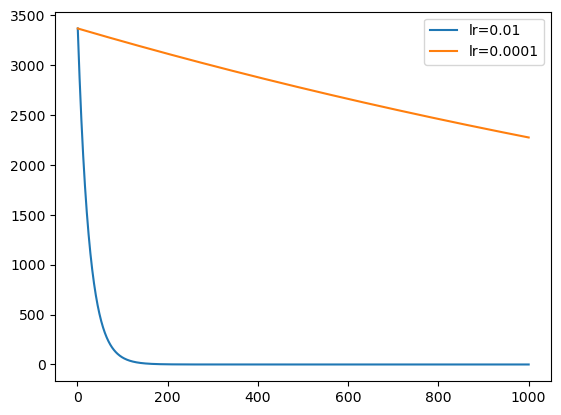

In [46]:
# Your code here:

def gradient_descent_mse(X, y, w, b, iterations= 10, learning_rate=.01):
    n = X.shape[0]

    mse_list = []
    
    for i in range(iterations):
        # compute the gradient 
        y_hat = X * w + b

        # compute the MSE
        mse_list.append((sum(y - y_hat)**2)/n)
        
        dL_dw = (-2/n) * X.T @ (y - y_hat)
        dL_db = (-2/n) * sum(y - y_hat)
    
        w -= (learning_rate * dL_dw)
        b -= (learning_rate * dL_db)

    return mse_list

fig, ax = plt.subplots()


learning_rates = [.0001, .01, 1.0]
learning_rates = [.01, .0001]
epochs = 1000


for alpha in learning_rates:
    # perform gradient descent and get MSE
    mse = gradient_descent_mse(X, y, w, b, iterations=epochs, learning_rate=alpha)
    # plot the loss (mse) with respect to iterations
    ax.plot(np.arange(1, epochs + 1), mse, label = f"lr={alpha}")
plt.legend()
plt.show()

## Exercise 3: Normal Equation

Implement the closed-form solution `w = (X^T X)^{-1} X^T y` and verify it gives the same weights as gradient descent.

In [47]:
# Remember to add a column of 1s to X for the bias term
# Your code here:
w = np.linalg.inv(X.T @ X) @ X.T @ y
print(f"w: {w}")

w: [[2.04923959]]


## Exercise 4: Mini-Batch Gradient Descent

Implement mini-batch GD with batch size 32. Compare convergence speed vs full-batch.

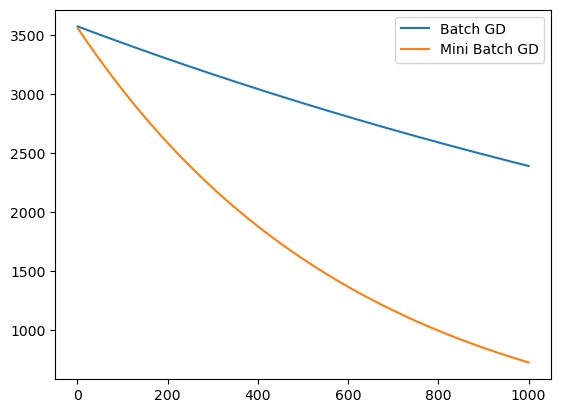

In [69]:
# Your code here:
'''
1. Shuffle the entire dataset                                                                                                                                
2. Split it into chunks of 32 (if 100 data points, you get 3 batches of 32 and 1 batch of 4)                                                                 
3. For each batch: compute the gradient using only those 32 points, update weights                                                                           
4. Once you've gone through all batches, that's one epoch (one full pass through the data)                                                                   
5. Repeat for many epochs  

'''

# (1) shuffle the dataset
indices = np.random.permutation(n)                                                                                                                           
X_shuffled = X[indices]
y_shuffled = y[indices]
 
# (2) split it into batches
batch_size = 32
indices = range(batch_size, n, batch_size)

# Split at those specific index positions
X_batches = np.split(X_shuffled, indices)
y_batches = np.split(y_shuffled, indices)



def mini_batch_gradient_descent_mse(X_batches, y_batches, w, b, iterations= 10, learning_rate=.01):

    mse_list = []
    
    for _ in range(iterations):
        for i in range(len(X_batches)):

            batch = X_batches[i]
            y = y_batches[i]
            
            n = batch.shape[0]
            # compute the gradient 
            y_hat = batch * w + b
    
            # compute the MSE
            
            
            dL_dw = (-2/n) * batch.T @ (y - y_hat)
            dL_db = (-2/n) * sum(y - y_hat)
        
            w -= (learning_rate * dL_dw)
            b -= (learning_rate * dL_db)

        mse_list.append((sum(y_shuffled - (X_shuffled * w + b))**2)/(X_shuffled.shape[0]))
    return mse_list



fig, ax = plt.subplots()

epochs = 1000



# perform gradient descent and get MSE
mse = gradient_descent_mse(X, y, w, b, iterations=epochs, learning_rate=alpha)
mse_batch = mini_batch_gradient_descent_mse(X_batches, y_batches, w, b, iterations=epochs, learning_rate=alpha)
# plot the loss (mse) with respect to iterations
ax.plot(np.arange(1, epochs + 1), mse, label = f"Batch GD")
ax.plot(np.arange(1, epochs + 1), mse_batch, label = f"Mini Batch GD")
plt.legend()
plt.show()



## Exercise 5: Polynomial Features — Overfitting vs Underfitting

Generate data from `y = 0.5x³ - 2x² + x + noise`. Fit polynomials of degree 1, 3, 5, 9, 15. Plot training vs validation error.

In [87]:
# Generate polynomial data
np.random.seed(42)
n = 50

def f_poly(X, w):
    return X @ w


X_poly = np.sort(np.random.randn(n, 1) * 2, axis=0)
#y_poly = 0.5 * X_poly**3 - 2 * X_poly**2 + X_poly + np.random.randn(n, 1) * 2
y_poly = 0.5 * X_poly**3 - 2 * X_poly**2 + X_poly + np.random.randn(n, 1) * 2
degree = 3
X_features = np.column_stack([X_poly**i for i in range(degree + 1)])

In [115]:
# Your code here:
def gradient_descent_polynomial(X, y, f, w, iterations= 10, learning_rate=.01):
    n = X.shape[0]

    #mse_list = []
    
    for i in range(iterations):
        # compute the gradient 
        y_hat = f(X, w)

        # compute the MSE
        #mse_list.append((sum(y - y_hat)**2)/n)
        '''
        print("X.shape: ", X.shape)
        print("X.T.shape: ", X.T.shape)
        print("y.shape: ", y.shape)
        print("y_hat.shape: ", y_hat.shape)
        '''
        dL_dw = (-2/n) * X.T @ (y - y_hat)
        #print("dL_dw.shape: ", dL_dw.shape)
        w -= (learning_rate * dL_dw)

    return w

w = np.ones((4, 1))
result = gradient_descent_polynomial(X_features, y_poly, f_poly, w, iterations=1000, learning_rate=.0001)
print(result)

[[ 0.56685008]
 [ 0.93626194]
 [-2.05414802]
 [ 0.50119264]]


## Exercise 6: Feature Standardization

Implement standardization (zero mean, unit variance) from scratch. Show that gradient descent converges faster on standardized features.

In [124]:
# Create a dataset with features on very different scales
np.random.seed(42)
n = 200
X_multi = np.column_stack([
    np.random.randn(n) * 1000,   # feature 1: large scale
    np.random.randn(n) * 0.01    # feature 2: tiny scale
])
y_multi = 2 * X_multi[:, 0] + 500 * X_multi[:, 1] + 3 + np.random.randn(n) * 0.5
y_multi = y_multi.reshape(-1, 1)

def my_func(X, w):
    return X @ w

print(X_multi.shape[0])

200


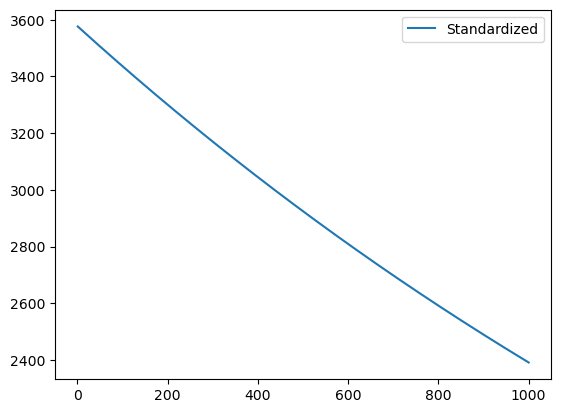

In [137]:
# Your code here:

# x_standardized = (x - mean) / std
mean = X_multi.mean(axis=0)
std = X_multi.std(axis=0)
# print(mean.shape)
X_standardized = (X_multi - mean) / std

# perform gradient descent on the non standardized and standardized

def gradient_descent_exercise_6(X, y, f, w, iterations= 100, learning_rate=.01):
    n = X.shape[0]

    mse_list = []
    
    for i in range(iterations):
        # compute the gradient 
        y_hat = f(X, w)

        # compute the MSE
        mse_list.append((sum(y - y_hat)**2)/n)
        '''        
        print("X.shape: ", X.shape)
        print("X.T.shape: ", X.T.shape)
        print("y.shape: ", y.shape)
        print("y_hat.shape: ", y_hat.shape)
        '''
        dL_dw = (-2/n) * X.T @ (y - y_hat)
        #print("dL_dw.shape: ", dL_dw.shape)
        w -= (learning_rate * dL_dw)

    return mse

fig, ax = plt.subplots()

epochs = 1000

w = np.ones((2, 1))

# perform gradient descent and get MSE
#mse_non_standardized = gradient_descent_exercise_6(X_multi, y_multi, my_func, w, iterations=epochs)
mse_standardized = gradient_descent_exercise_6(X_standardized, y_multi, my_func, w, iterations=epochs)

# plot the loss (mse) with respect to iterations
#ax.plot(np.arange(1, epochs + 1), mse_non_standardized, label = f"Non-standardized")
ax.plot(np.arange(1, epochs + 1), mse_standardized, label = f"Standardized")
plt.legend()
plt.show()

# non standarized data results in inf and nan when performing predictions


## Exercise 7: Compare Against sklearn

Use `sklearn.linear_model.LinearRegression` on the same data and verify you get the same weights.

In [139]:
from sklearn.linear_model import LinearRegression

# Your code here:
model = LinearRegression(fit_intercept=True, copy_X=True, n_jobs=None, positive=False)

model.fit(X_standardized, y_multi)

# 2. Extract the calculated slope(s) and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[1857.28139098    4.91273133]]
Intercept: [-78.15541693]
